# Pareto Sampling Report

This notebook reads one or more `points.csv` files produced by `src/sample_exp.py`, builds Pareto fronts for every sampled run, and compares selected experiments.

Expected `points.csv` columns:

- `circuit`
- `run_id`
- `size`
- `depth`

Rows with missing `run_id` are treated as the original circuit point and are used for normalization.

In [4]:
from __future__ import annotations

from itertools import product
from pathlib import Path
from statistics import fmean, pstdev

import pandas as pd

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)

## Inputs

Set `points_csv_paths` to the `points.csv` files you want to compare. By default, `run_name` is inferred from the parent experiment directory name.

In [5]:
# Fill this list with paths to points.csv files produced by src/sample_exp.py.
points_csv_paths = [
    # "../outputs/2026-05-26/12:06_tb_zhu_i10_79035/points.csv",
]

output_dir = Path('../outputs')
points_csv_paths = list(filter(lambda p: p.name == 'points.csv', output_dir.glob('**/*.csv')))
print(len(points_csv_paths))

# Optional friendly labels. If a path is missing here, its parent directory name is used.
run_name_overrides = {
    # "../outputs/2026-05-26/12:06_tb_zhu_i10_79035/points.csv": "gflownet_tb",
}
run_name_overrides = {str(p): '_'.join(p.parent.name.split('_')[1:-1]) for p in points_csv_paths}
print(run_name_overrides)

30
{'../outputs/2026-06-02/01:49:15_tbzhuLinear0_k2_81413/points.csv': 'tbzhuLinear0_k2', '../outputs/2026-06-02/01:51:19_tbzhuDOP0_k2_81414/points.csv': 'tbzhuDOP0_k2', '../outputs/2026-06-02/00:23:02_tbzhuDOP0_dalu_81414/points.csv': 'tbzhuDOP0_dalu', '../outputs/2026-06-02/00:21:33_tbzhuLinear0_dalu_81413/points.csv': 'tbzhuLinear0_dalu', '../outputs/2026-07-08/07:29:33_tbzhuDOP_apex1_10373/points.csv': 'tbzhuDOP_apex1', '../outputs/2026-07-08/07:29:33_tbzhuDOP_bc0_10372/points.csv': 'tbzhuDOP_bc0', '../outputs/2026-07-08/07:29:33_tbzhuDOP_C5315_10374/points.csv': 'tbzhuDOP_C5315', '../outputs/2026-07-08/08:25:10_tbzhuDOP_k2_10376/points.csv': 'tbzhuDOP_k2', '../outputs/2026-07-08/08:06:02_tbzhuDOP_dalu_10375/points.csv': 'tbzhuDOP_dalu', '../outputs/2026-07-08/07:28:57_tbzhuDOP_C1355_10371/points.csv': 'tbzhuDOP_C1355', '../outputs/2026-06-01/18:39:38_zhuLinear_k2_81399/points.csv': 'zhuLinear_k2', '../outputs/2026-06-01/19:58:48_tbzhuDOP0_bc0_81414/points.csv': 'tbzhuDOP0_bc0', '.

## Pareto Helpers

The notebook minimizes normalized `(size, depth)`, where the original circuit is `(1, 1)`. Hypervolume is the area dominated by the Pareto front and bounded by the original circuit reference point.

In [6]:
def weakly_dominates_min(a, b):
    """Return True when point a weakly dominates point b in minimization space."""
    return a[0] <= b[0] and a[1] <= b[1]


def strictly_dominates_min(a, b):
    return weakly_dominates_min(a, b) and (a[0] < b[0] or a[1] < b[1])


def pareto_front_min(points):
    """Deduplicated nondominated points for 2D minimization."""
    unique_points = sorted(set((float(x), float(y)) for x, y in points), key=lambda p: (p[0], p[1]))
    return [
        point
        for point in unique_points
        if not any(strictly_dominates_min(other, point) for other in unique_points)
    ]


def hypervolume_min_2d(points, reference=(1.0, 1.0)):
    """2D minimization hypervolume relative to the original circuit point."""
    front = pareto_front_min(points)
    clipped = sorted(
        {
            (max(0.0, min(reference[0], x)), max(0.0, min(reference[1], y)))
            for x, y in front
            if x < reference[0] and y < reference[1]
        },
        key=lambda p: p[0],
    )
    hv = 0.0
    for idx, (x, y) in enumerate(clipped):
        next_x = clipped[idx + 1][0] if idx + 1 < len(clipped) else reference[0]
        hv += max(0.0, next_x - x) * max(0.0, reference[1] - y)
    return float(hv)


def additive_epsilon_min(source_points, target_points):
    """Smallest eps such that source weakly epsilon-dominates target in minimization space."""
    source_front = pareto_front_min(source_points)
    target_front = pareto_front_min(target_points)
    if not target_front:
        return 0.0
    if not source_front:
        return float("inf")
    return float(
        max(
            min(max(source[0] - target[0], source[1] - target[1]) for source in source_front)
            for target in target_front
        )
    )


def dominance_ratio_min(source_points, target_points):
    """Fraction of target front points weakly dominated by the source front."""
    source_front = pareto_front_min(source_points)
    target_front = pareto_front_min(target_points)
    if not target_front:
        return 0.0
    dominated = sum(
        1
        for target in target_front
        if any(weakly_dominates_min(source, target) for source in source_front)
    )
    return float(dominated / len(target_front))


def summarize(values):
    values = [float(v) for v in values]
    if not values:
        return {"n": 0, "mean": None, "std": None, "stderr": None, "min": None, "max": None}
    std = pstdev(values) if len(values) > 1 else 0.0
    return {
        "n": len(values),
        "mean": fmean(values),
        "std": std,
        "stderr": std / (len(values) ** 0.5),
        "min": min(values),
        "max": max(values),
    }

## Load Points And Build Per-Run Metrics

`points_df` contains all normalized sampled points. `summary_df` is the requested dataframe with one row per `(run_name, run_id, circuit)`.

In [7]:
def resolve_path(path_like):
    path = Path(path_like).expanduser()
    if path.is_absolute():
        return path
    return (Path.cwd() / path).resolve()


def load_points_csv(path_like, run_name=None):
    path = resolve_path(path_like)
    df = pd.read_csv(path)
    required = {"circuit", "run_id", "size", "depth"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} is missing required columns: {sorted(missing)}")

    df = df.copy()
    df["points_csv"] = str(path)
    df["run_name"] = run_name or path.parent.name
    df["run_id"] = pd.to_numeric(df["run_id"], errors="coerce").astype("Int64")
    df["size"] = pd.to_numeric(df["size"])
    df["depth"] = pd.to_numeric(df["depth"])
    return df


frames = []
for path_like in points_csv_paths:
    path_key = str(path_like)
    frames.append(load_points_csv(path_like, run_name=run_name_overrides.get(path_key)))

if not frames:
    raise ValueError("Fill points_csv_paths with at least one points.csv path, then rerun this cell.")

raw_points_df = pd.concat(frames, ignore_index=True)

initial_df = (
    raw_points_df[raw_points_df["run_id"].isna()]
    .drop_duplicates(subset=["run_name", "circuit"])
    [["run_name", "circuit", "size", "depth"]]
    .rename(columns={"size": "initial_size", "depth": "initial_depth"})
)

sample_df = raw_points_df[raw_points_df["run_id"].notna()].copy()
points_df = sample_df.merge(initial_df, on=["run_name", "circuit"], how="left", validate="many_to_one")
if points_df[["initial_size", "initial_depth"]].isna().any().any():
    missing = points_df[points_df[["initial_size", "initial_depth"]].isna().any(axis=1)][["run_name", "circuit"]].drop_duplicates()
    raise ValueError(f"Missing original-circuit rows for:\n{missing}")

points_df["normalized_size"] = points_df["size"] / points_df["initial_size"]
points_df["normalized_depth"] = points_df["depth"] / points_df["initial_depth"]
points_df["size_reduction"] = 1.0 - points_df["normalized_size"]
points_df["depth_reduction"] = 1.0 - points_df["normalized_depth"]
points_df['circuit'] = points_df['circuit'].map(lambda x: x.split('/')[-1].split('.')[0])

rows = []
fronts = {}
for (run_name, run_id, circuit), group in points_df.groupby(["run_name", "run_id", "circuit"], dropna=False):
    points = list(zip(group["normalized_size"], group["normalized_depth"]))
    front = pareto_front_min(points)
    fronts[(run_name, int(run_id), circuit)] = front
    rows.append(
        {
            "run_name": run_name,
            "run_id": int(run_id),
            "circuit": circuit,
            "hypervolume": hypervolume_min_2d(front),
            "number of nondominated points": len(front),
        }
    )

summary_df = pd.DataFrame(rows).sort_values(["circuit", "run_name", "run_id"]).reset_index(drop=True)
# summary_df['circuit'] = summary_df['circuit'].map(lambda x: x.split('/')[-1].split('.')[0])
# print((summary_df.loc[0, 'circuit']))
# summary_df.loc[summary_df['run_name'].str.startswith('ppo')]
print(summary_df['run_name'].unique())
summary_df

['tbzhuDOP0_c1355' 'tbzhuDOP_C1355' 'tbzhuLinear0_c1355' 'zhuDOP_c1355'
 'zhuLinear_c1355' 'tbzhuDOP0_c5315' 'tbzhuDOP_C5315' 'tbzhuLinear0_c5315'
 'zhuDOP_c5315' 'zhuLinear_c5315' 'tbzhuDOP0_apex1' 'tbzhuDOP_apex1'
 'tbzhuLinear0_apex1' 'zhuDOP_apex1' 'zhuLinear_apex1' 'tbzhuDOP0_bc0'
 'tbzhuDOP_bc0' 'tbzhuLinear0_bc0' 'zhuDOP_bc0' 'zhuLinear_bc0'
 'tbzhuDOP0_dalu' 'tbzhuDOP_dalu' 'tbzhuLinear0_dalu' 'zhuDOP_dalu'
 'zhuLinear_dalu' 'tbzhuDOP0_k2' 'tbzhuDOP_k2' 'tbzhuLinear0_k2'
 'zhuDOP_k2' 'zhuLinear_k2']


,run_name,run_id,circuit,hypervolume,number of nondominated points
0,tbzhuDOP0_c1355,0,C1355,0.081044,1
1,tbzhuDOP0_c1355,1,C1355,0.081044,1
2,tbzhuDOP0_c1355,2,C1355,0.071963,2
3,tbzhuDOP0_c1355,3,C1355,0.072039,1
4,tbzhuDOP0_c1355,4,C1355,0.080815,3
...,...,...,...,...,...
295,zhuLinear_k2,5,k2,0.180507,2
296,zhuLinear_k2,6,k2,0.180964,2
297,zhuLinear_k2,7,k2,0.192410,3
298,zhuLinear_k2,8,k2,0.167842,1


## Average Metrics Across Runs

This aggregates the per-run dataframe by experiment and circuit, which is useful for RL/GFlowNet comparisons over multiple trained policies.

In [8]:
aggregate_summary_df = (
    summary_df.groupby(["run_name", "circuit"])
    .agg(
        n_runs=("run_id", "nunique"),
        hypervolume_mean=("hypervolume", "mean"),
        hypervolume_std=("hypervolume", "std"),
        hypervolume_min=("hypervolume", "min"),
        hypervolume_max=("hypervolume", "max"),
        nondominated_mean=("number of nondominated points", "mean"),
        nondominated_std=("number of nondominated points", "std"),
        nondominated_min=("number of nondominated points", "min"),
        nondominated_max=("number of nondominated points", "max"),
    )
    .reset_index()
)
aggregate_summary_df["hypervolume_stderr"] = aggregate_summary_df["hypervolume_std"] / aggregate_summary_df["n_runs"].pow(0.5)
aggregate_summary_df["nondominated_stderr"] = aggregate_summary_df["nondominated_std"] / aggregate_summary_df["n_runs"].pow(0.5)
aggregate_summary_df

,run_name,circuit,n_runs,hypervolume_mean,hypervolume_std,hypervolume_min,hypervolume_max,nondominated_mean,nondominated_std,nondominated_min,nondominated_max,hypervolume_stderr,nondominated_stderr
0,tbzhuDOP0_apex1,apex1,10,0.098350,0.005023,0.091790,0.103620,2.8,0.918937,2,4,0.001588,0.290593
1,tbzhuDOP0_bc0,bc0,10,0.211114,0.007436,0.201978,0.220457,3.1,1.100505,1,4,0.002351,0.348010
2,tbzhuDOP0_c1355,C1355,10,0.075557,0.006229,0.063034,0.081044,1.6,0.843274,1,3,0.001970,0.266667
3,tbzhuDOP0_c5315,C5315,10,0.077858,0.006756,0.067088,0.090851,2.3,1.059350,1,4,0.002136,0.334996
4,tbzhuDOP0_dalu,dalu,10,0.000000,0.000000,0.000000,0.000000,1.8,0.632456,1,3,0.000000,0.200000
5,tbzhuDOP0_k2,k2,10,0.197093,0.003165,0.192736,0.201397,3.3,1.337494,2,5,0.001001,0.422953
6,tbzhuDOP_C1355,C1355,10,0.075588,0.004614,0.071963,0.081044,1.5,0.527046,1,2,0.001459,0.166667
7,tbzhuDOP_C5315,C5315,10,0.075575,0.004696,0.070754,0.085374,2.9,0.994429,1,4,0.001485,0.314466
8,tbzhuDOP_apex1,apex1,10,0.104756,0.008458,0.091595,0.115282,3.4,0.843274,2,4,0.002675,0.266667
9,tbzhuDOP_bc0,bc0,10,0.222267,0.005450,0.218613,0.237214,3.7,0.674949,3,5,0.001723,0.213437


## Pairwise Experiment Comparison

Choose a circuit and a set of experiments. Pairwise values are computed over all run pairs between two experiments and then summarized.

In [36]:
# Choose the comparison target.
selected_circuit = points_df["circuit"].unique()[0]
# selected_circuit = 'bc0'
_selected_experiments = points_df.loc[points_df["circuit"] == selected_circuit]
selected_experiments = sorted(_selected_experiments["run_name"].unique())


print("Selected circuit:", selected_circuit)
print("Selected experiments:", selected_experiments)

circ_sum_df = summary_df.loc[
    summary_df["circuit"] == selected_circuit,
    ["run_name", "hypervolume", "number of nondominated points"]
].groupby("run_name").agg("mean")
circ_sum_df

Selected circuit: k2
Selected experiments: ['tbzhuDOP0_k2', 'tbzhuDOP_k2', 'tbzhuLinear0_k2', 'zhuDOP_k2', 'zhuLinear_k2']


,hypervolume,number of nondominated points
run_name,,
tbzhuDOP0_k2,0.197093,3.3
tbzhuDOP_k2,0.186933,2.6
tbzhuLinear0_k2,0.195987,3.0
zhuDOP_k2,0.185690,2.5
zhuLinear_k2,0.183013,2.3


In [37]:
def run_fronts_for(run_name, circuit):
    run_rows = summary_df[(summary_df["run_name"] == run_name) & (summary_df["circuit"] == circuit)]
    return {
        int(row.run_id): fronts[(run_name, int(row.run_id), circuit)]
        for row in run_rows.itertuples(index=False)
    }


pairwise_rows = []
for source_name, target_name in product(selected_experiments, repeat=2):
    if source_name == target_name:
        continue
    source_fronts = run_fronts_for(source_name, selected_circuit)
    target_fronts = run_fronts_for(target_name, selected_circuit)

    eps_values = []
    dominance_values = []
    for source_run_id, source_front in source_fronts.items():
        for target_run_id, target_front in target_fronts.items():
            eps_values.append(additive_epsilon_min(source_front, target_front))
            dominance_values.append(dominance_ratio_min(source_front, target_front))

    eps_summary = summarize(eps_values)
    dominance_summary = summarize(dominance_values)
    pairwise_rows.append(
        {
            "source_run_name": source_name,
            "target_run_name": target_name,
            "circuit": selected_circuit,
            "n_run_pairs": eps_summary["n"],
            "additive_epsilon_mean": eps_summary["mean"],
            "additive_epsilon_std": eps_summary["std"],
            "additive_epsilon_stderr": eps_summary["stderr"],
            "additive_epsilon_min": eps_summary["min"],
            "additive_epsilon_max": eps_summary["max"],
            "dominance_ratio_mean": dominance_summary["mean"],
            "dominance_ratio_std": dominance_summary["std"],
            "dominance_ratio_stderr": dominance_summary["stderr"],
            "dominance_ratio_min": dominance_summary["min"],
            "dominance_ratio_max": dominance_summary["max"],
        }
    )

pairwise_df = pd.DataFrame(pairwise_rows)
pairwise_df

,source_run_name,target_run_name,circuit,n_run_pairs,additive_epsilon_mean,additive_epsilon_std,additive_epsilon_stderr,additive_epsilon_min,additive_epsilon_max,dominance_ratio_mean,dominance_ratio_std,dominance_ratio_stderr,dominance_ratio_min,dominance_ratio_max
0,tbzhuDOP0_k2,tbzhuDOP_k2,k2,100,0.019272,0.010466,0.001047,0.000000,0.043478,0.158333,0.261539,0.026154,0.000000,1.000000
1,tbzhuDOP0_k2,tbzhuLinear0_k2,k2,100,0.013526,0.012983,0.001298,0.000000,0.043478,0.515000,0.364932,0.036493,0.000000,1.000000
2,tbzhuDOP0_k2,zhuDOP_k2,k2,100,0.002518,0.005320,0.000532,0.000000,0.024024,0.848333,0.235814,0.023581,0.000000,1.000000
3,tbzhuDOP0_k2,zhuLinear_k2,k2,100,0.001697,0.006202,0.000620,-0.016016,0.032533,0.910000,0.178606,0.017861,0.333333,1.000000
4,tbzhuDOP_k2,tbzhuDOP0_k2,k2,100,0.035909,0.015587,0.001559,0.000000,0.043478,0.553000,0.325375,0.032537,0.000000,1.000000
5,tbzhuDOP_k2,tbzhuLinear0_k2,k2,100,0.035909,0.015745,0.001575,0.000000,0.043478,0.578500,0.288206,0.028821,0.000000,1.000000
6,tbzhuDOP_k2,zhuDOP_k2,k2,100,0.034788,0.017381,0.001738,0.000000,0.043478,0.663333,0.179475,0.017947,0.500000,1.000000
7,tbzhuDOP_k2,zhuLinear_k2,k2,100,0.031109,0.020056,0.002006,-0.028529,0.043478,0.686667,0.204505,0.020450,0.333333,1.000000
8,tbzhuLinear0_k2,tbzhuDOP0_k2,k2,100,0.015164,0.013086,0.001309,0.000000,0.043478,0.441333,0.361421,0.036142,0.000000,1.000000
9,tbzhuLinear0_k2,tbzhuDOP_k2,k2,100,0.022609,0.011028,0.001103,0.000501,0.048048,0.084167,0.178534,0.017853,0.000000,0.666667


## Print Selected Pareto Fronts

This prints a Pareto front for each selected experiment on the chosen circuit. The front is pooled across selected runs for that experiment, then filtered again for nondominated normalized `(size, depth)` points.

In [38]:
# Choose which runs to include in the printed front. None means all runs for each experiment.
selected_run_ids = None  # example: [0, 1, 2]

front_rows = []
for run_name in selected_experiments:
    subset = points_df[(points_df["run_name"] == run_name) & (points_df["circuit"] == selected_circuit)]
    if selected_run_ids is not None:
        subset = subset[subset["run_id"].isin(selected_run_ids)]

    pooled_points = list(zip(subset["normalized_size"], subset["normalized_depth"]))
    pooled_front = pareto_front_min(pooled_points)
    for normalized_size, normalized_depth in pooled_front:
        matching = subset[
            (subset["normalized_size"] == normalized_size)
            & (subset["normalized_depth"] == normalized_depth)
        ].iloc[0]
        front_rows.append(
            {
                "run_name": run_name,
                "circuit": selected_circuit,
                "normalized_size": normalized_size,
                "normalized_depth": normalized_depth,
                "size_reduction": 1.0 - normalized_size,
                "depth_reduction": 1.0 - normalized_depth,
                "size": int(matching["size"]),
                "depth": int(matching["depth"]),
            }
        )

selected_front_df = pd.DataFrame(front_rows).sort_values(
    ["run_name", "normalized_size", "normalized_depth"]
).reset_index(drop=True)

print(f"Pareto fronts for circuit: {selected_circuit}")
print(f"Experiments: {selected_experiments}")
print(selected_front_df.to_string(index=False))
selected_front_df

Pareto fronts for circuit: k2
Experiments: ['tbzhuDOP0_k2', 'tbzhuDOP_k2', 'tbzhuLinear0_k2', 'zhuDOP_k2', 'zhuLinear_k2']
       run_name circuit  normalized_size  normalized_depth  size_reduction  depth_reduction  size  depth
   tbzhuDOP0_k2      k2         0.532032          0.652174        0.467968         0.347826  1063     15
   tbzhuDOP0_k2      k2         0.534034          0.608696        0.465966         0.391304  1067     14
   tbzhuDOP0_k2      k2         0.555055          0.565217        0.444945         0.434783  1109     13
    tbzhuDOP_k2      k2         0.521021          1.043478        0.478979        -0.043478  1041     24
    tbzhuDOP_k2      k2         0.523023          0.782609        0.476977         0.217391  1045     18
    tbzhuDOP_k2      k2         0.524525          0.652174        0.475475         0.347826  1048     15
    tbzhuDOP_k2      k2         0.526026          0.608696        0.473974         0.391304  1051     14
    tbzhuDOP_k2      k2         0.542

,run_name,circuit,normalized_size,normalized_depth,size_reduction,depth_reduction,size,depth
0,tbzhuDOP0_k2,k2,0.532032,0.652174,0.467968,0.347826,1063,15
1,tbzhuDOP0_k2,k2,0.534034,0.608696,0.465966,0.391304,1067,14
2,tbzhuDOP0_k2,k2,0.555055,0.565217,0.444945,0.434783,1109,13
3,tbzhuDOP_k2,k2,0.521021,1.043478,0.478979,-0.043478,1041,24
4,tbzhuDOP_k2,k2,0.523023,0.782609,0.476977,0.217391,1045,18
5,tbzhuDOP_k2,k2,0.524525,0.652174,0.475475,0.347826,1048,15
6,tbzhuDOP_k2,k2,0.526026,0.608696,0.473974,0.391304,1051,14
7,tbzhuDOP_k2,k2,0.542543,0.565217,0.457457,0.434783,1084,13
8,tbzhuLinear0_k2,k2,0.535536,0.608696,0.464464,0.391304,1070,14
9,tbzhuLinear0_k2,k2,0.551051,0.565217,0.448949,0.434783,1101,13


## Plot Selected Pareto Fronts

This plots the pooled Pareto front for each selected experiment on the selected circuit in normalized minimization space. Lower-left is better.

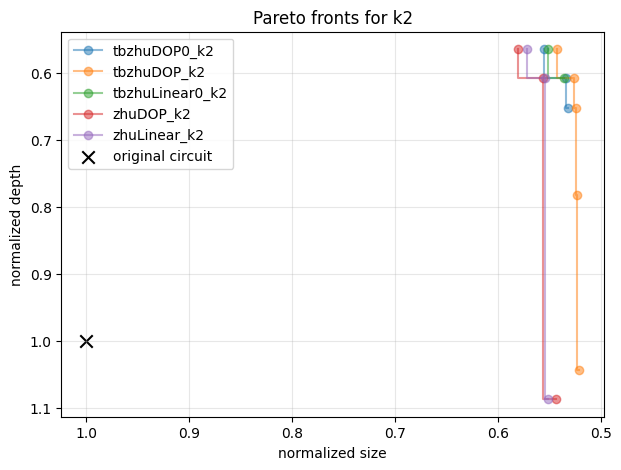

In [39]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

for run_name in selected_experiments:
    front = selected_front_df[selected_front_df["run_name"] == run_name].sort_values(
        ["normalized_size", "normalized_depth"]
    )
    if front.empty:
        continue
    ax.step(
        front["normalized_size"],
        front["normalized_depth"],
        where="post",
        marker="o",
        alpha=0.5,
        label=run_name,
    )

ax.scatter([1.0], [1.0], marker="x", s=80, color="black", label="original circuit")
ax.set_xlabel("normalized size")
ax.set_ylabel("normalized depth")
ax.set_title(f"Pareto fronts for {Path(selected_circuit).name}")
ax.grid(True, alpha=0.3)
ax.legend()
ax.invert_xaxis()
ax.invert_yaxis()
plt.show()